# DSCI 521 Final Project: Feature Engineering and Modeling Notebook

In this notebook we will be exploring the prediction capability of the dataset. We aim to explore the idea of better shot selection during rallies which can lead to more points won and more games won.

**What do we know so far in the data?**
-

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np

## Data Import

In [4]:
data_path = "/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/shot_rally.csv"

In [5]:
df = pd.read_csv(data_path)

In [6]:
df.head(10)

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
0,289847,M99,G178,R7807,65,4,T135,T136,T135,S72059,...,P183,6.05,8.08,NaN,NaN,Unforced Error,Unforced Error,Game Over,NaN,NaN
1,289846,M99,G178,R7807,65,4,T135,T136,T135,S72058,...,P182,8.71,-20.58,6.05,8.08,Unforced Error,Winner,Game Over,HB,NaN
2,289845,M99,G178,R7807,65,4,T135,T136,T135,S72057,...,P184,17.53,20.76,8.71,-20.58,Unforced Error,Extend Rally,Game Over,tsDrv,HB
3,289844,M99,G178,R7807,65,4,T135,T136,T135,S72056,...,P181,7.42,-20.94,17.53,20.76,Unforced Error,Start Rally,Game Over,R,tsDrv
4,289843,M99,G178,R7806,64,4,T135,T136,T135,S72055,...,P184,11.56,7.72,NaN,NaN,Unforced Error,Unforced Error,Point,NaN,NaN
5,289842,M99,G178,R7806,64,4,T135,T136,T135,S72054,...,P181,14.96,-19.84,11.56,7.72,Unforced Error,Winner,Point,HB,NaN
6,289841,M99,G178,R7806,64,4,T135,T136,T135,S72053,...,P183,2.74,20.58,14.96,-19.84,Unforced Error,Extend Rally,Point,tsDrv,HB
7,289840,M99,G178,R7806,64,4,T135,T136,T135,S72052,...,P181,15.60,-21.04,2.74,20.58,Unforced Error,Start Rally,Point,R,tsDrv
8,289839,M99,G178,R7805,63,8,T135,T136,T135,S72051,...,P183,3.38,7.90,NaN,NaN,Unforced Error,Unforced Error,Point,NaN,NaN
9,289838,M99,G178,R7805,63,8,T135,T136,T135,S72050,...,P182,8.62,-20.30,3.38,7.90,Unforced Error,Extend Rally,Point,HB,NaN


In [ ]:
# We would also like to have the model have access to player ratings to help

## Data Engineering

So for this section of the project there are two ways that we can go about it.

1. Let the data speak for itself and do a relational matrix that

In [7]:
sorted_df = df.sort_values(['match_id','game_id','rally_id', 'rally_nbr','shot_nbr'], ascending=True)

In [8]:
sorted_df.head(10)

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,player_id,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type
304429,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,P23,12.11,-25.83,1.33,26.35,Other,Start Rally,Side Out,R,tsDrp
304428,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,P25,1.33,26.35,12.91,-25.24,Other,Extend Rally,Side Out,tsDrp,HB
304427,290877,M10,G18,R814,1,5,T13,T14,T14,S8560,...,P23,12.91,-25.24,18.87,8.72,Other,Extend Rally,Side Out,HB,HB
304426,290878,M10,G18,R814,1,5,T13,T14,T14,S8561,...,P26,18.87,8.72,12.37,-17.52,Other,Extend Rally,Side Out,HB,NaN
304425,290879,M10,G18,R814,1,5,T13,T14,T14,S8562,...,P24,12.37,-17.52,NaN,NaN,Other,Other,Side Out,NaN,NaN
304424,290960,M10,G18,R815,2,3,T14,T13,T13,S8563,...,P25,15.45,-26.79,3.88,26.41,Unforced Error,Start Rally,Next Server,R,tsDrp
304423,290961,M10,G18,R815,2,3,T14,T13,T13,S8564,...,P23,3.88,26.41,15.99,-26.35,Unforced Error,Extend Rally,Next Server,tsDrp,NaN
304422,290962,M10,G18,R815,2,3,T14,T13,T13,S8565,...,P25,15.99,-26.35,NaN,NaN,Unforced Error,Unforced Error,Next Server,NaN,NaN
304421,291049,M10,G18,R816,3,10,T14,T13,T13,S8566,...,P26,4.21,-26.06,16.87,26.27,Winner,Start Rally,Side Out,R,tsDrp
304420,291050,M10,G18,R816,3,10,T14,T13,T13,S8567,...,P24,16.87,26.27,-0.88,-22.27,Winner,Extend Rally,Side Out,tsDrp,D


In [9]:
sorted_df['rally_outcome'].value_counts()

,count
rally_outcome,
Point,127940
Side Out,97574
Next Server,71442
Game Over,7474


First we need to create a good gague of what rallies win points or not. In the case of pickleball points can only be scored when the team that serves the ball wins the point so we can take a win as the serving team winning the rally.

Now another complicated nuance of pickleball especially for doubles is the Start of game and Serving convention.

In [ ]:
# First lets get a good gague on what rallies win or not

In [10]:
# shot distance, to help us
import math

sorted_df['shot_distance'] = np.sqrt((sorted_df['loc_x'] - sorted_df['next_loc_x'])**2 + (sorted_df['loc_y'] - sorted_df['next_loc_y'])**2)

In [11]:
sorted_df.head()

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,loc_x,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type,shot_distance
304429,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,12.11,-25.83,1.33,26.35,Other,Start Rally,Side Out,R,tsDrp,53.281899
304428,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,1.33,26.35,12.91,-25.24,Other,Extend Rally,Side Out,tsDrp,HB,52.873665
304427,290877,M10,G18,R814,1,5,T13,T14,T14,S8560,...,12.91,-25.24,18.87,8.72,Other,Extend Rally,Side Out,HB,HB,34.479026
304426,290878,M10,G18,R814,1,5,T13,T14,T14,S8561,...,18.87,8.72,12.37,-17.52,Other,Extend Rally,Side Out,HB,NaN,27.033083
304425,290879,M10,G18,R814,1,5,T13,T14,T14,S8562,...,12.37,-17.52,NaN,NaN,Other,Other,Side Out,NaN,NaN,NaN


In [12]:
dy = sorted_df['next_loc_y'] - sorted_df['loc_y']
dx = sorted_df['next_loc_x'] - sorted_df['loc_x']

sorted_df['shot_angle'] = np.arctan(dx, dy)

# Previous shot angle method was to use the gradient but will run into issues due to possibility of straight shots where gradient tends to infinity
#sorted_df['shot_dir'] = (sorted_df['next_loc_y'] - sorted_df['loc_y']) / (sorted_df['next_loc_x'] - sorted_df['loc_x'])

In [13]:
sorted_df.head()

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,loc_y,next_loc_x,next_loc_y,ending_type,shot_outcome,rally_outcome,next_shot_type,next_2-shot_type,shot_distance,shot_angle
304429,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,-25.83,1.33,26.35,Other,Start Rally,Side Out,R,tsDrp,53.281899,1.774523
304428,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,26.35,12.91,-25.24,Other,Extend Rally,Side Out,tsDrp,HB,52.873665,-1.349994
304427,290877,M10,G18,R814,1,5,T13,T14,T14,S8560,...,-25.24,18.87,8.72,Other,Extend Rally,Side Out,HB,HB,34.479026,1.397065
304426,290878,M10,G18,R814,1,5,T13,T14,T14,S8561,...,8.72,12.37,-17.52,Other,Extend Rally,Side Out,HB,NaN,27.033083,-1.813622
304425,290879,M10,G18,R814,1,5,T13,T14,T14,S8562,...,-17.52,NaN,NaN,Other,Other,Side Out,NaN,NaN,NaN,NaN


In [14]:
# now to create the indicator variable for point won
# This will be quite simple to do as it will be the indication if the serving team is the team that
# won the point

# We also chose to create a defensive point indicator as a way to help people playing the return of serve
# So there will be two different models at play here!

sorted_df['srv_point_won'] = (sorted_df['srv_team_id'] == sorted_df['w_team_id']).astype(int)
sorted_df['def_point_won'] = (sorted_df['srv_team_id'] != sorted_df['w_team_id']).astype(int)

In [15]:
sorted_df['srv_point_won'].value_counts()
sorted_df['def_point_won'].value_counts()

,count
def_point_won,
1,169256
0,135174


The next step will be to remove the next shot columns as we are trying to create a predictive model and so any information that tells the future outcomes will have to be dropped in this context.

To replace these columns we will add a previous shot column, which will aluse to both the opponents shot selection and the location that they hit the shot from

In [16]:
new_df = sorted_df.sort_values(['match_id', 'game_id', 'rally_id', 'shot_nbr']).copy()

# 2. Define the group once to reuse
rally_grp = new_df.groupby(['match_id', 'game_id', 'rally_id'])

# 3. Add previous shot types
new_df['prev_shot_type'] = rally_grp['shot_type'].shift(1)
new_df['prev_prev_shot_type'] = rally_grp['shot_type'].shift(2)

# 4. Add previous shot locations (Where the ball landed)
new_df['prev_loc_x'] = rally_grp['loc_x'].shift(1)
new_df['prev_loc_y'] = rally_grp['loc_y'].shift(1)

# 5. Add where the previous shot STARTED (to get direction)
new_df['prev_prev_loc_x'] = new_df['prev_loc_x'].shift(1) # or use 'prev_loc_x' if available
new_df['prev_prev_loc_y'] = new_df['prev_loc_y'].shift(1)


# 6. Adding the previous shot angles as it will be an indicator of where the possible next shot will go
new_df['prev_shot_angle'] = new_df['shot_angle'].shift(1)
new_df['prev_prev_shot_angle'] = new_df['prev_shot_angle'].shift(1)


# Droping the next shot column
new_df = new_df.drop(columns=['next_shot_type', 'next_2-shot_type'])

In [17]:
new_df.head(20)

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,srv_point_won,def_point_won,prev_shot_type,prev_prev_shot_type,prev_loc_x,prev_loc_y,prev_prev_loc_x,prev_prev_loc_y,prev_shot_angle,prev_prev_shot_angle
304429,290875,M10,G18,R814,1,5,T13,T14,T14,S8558,...,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
304428,290876,M10,G18,R814,1,5,T13,T14,T14,S8559,...,0,1,SE,NaN,12.11,-25.83,NaN,NaN,1.774523,NaN
304427,290877,M10,G18,R814,1,5,T13,T14,T14,S8560,...,0,1,R,SE,1.33,26.35,12.11,-25.83,-1.349994,1.774523
304426,290878,M10,G18,R814,1,5,T13,T14,T14,S8561,...,0,1,tsDrp,R,12.91,-25.24,1.33,26.35,1.397065,-1.349994
304425,290879,M10,G18,R814,1,5,T13,T14,T14,S8562,...,0,1,HB,tsDrp,18.87,8.72,12.91,-25.24,-1.813622,1.397065
304424,290960,M10,G18,R815,2,3,T14,T13,T13,S8563,...,0,1,NaN,NaN,NaN,NaN,18.87,8.72,NaN,-1.813622
304423,290961,M10,G18,R815,2,3,T14,T13,T13,S8564,...,0,1,SE,NaN,15.45,-26.79,NaN,NaN,1.784943,NaN
304422,290962,M10,G18,R815,2,3,T14,T13,T13,S8565,...,0,1,R,SE,3.88,26.41,15.45,-26.79,-1.345174,1.784943
304421,291049,M10,G18,R816,3,10,T14,T13,T13,S8566,...,0,1,NaN,NaN,NaN,NaN,3.88,26.41,NaN,-1.345174
304420,291050,M10,G18,R816,3,10,T14,T13,T13,S8567,...,0,1,SE,NaN,4.21,-26.06,NaN,NaN,1.333431,NaN


Can we predict the rally outcome given the first 3 shots of the rally
Find singnals that the first three shots matter

Based on style of serve and see if there is any difference in signal there on the serve distances

1. Does location of third shot affect how t

Flip the arctan calculations for shot direction.

## Preditiction ideas

This is option 2 of our pickleball shot recommender system where we will try to see if using machine learning algorithms can help make better decisions in any given rally.

**What do we want the machine learning model to tell us?**

1. Given any location in the current rally (*once previous shots have been seen by the model*), Can the machine learning algorithm lay out the best shot options that can lead to a higher win probability.


### Filling in Null Values

In [18]:
#filling nan values for previous shot with 'Rally Start'
new_df['prev_shot_type'] = new_df['prev_shot_type'].fillna('Rally Start')

#filling nan values for previ
new_df['prev_prev_shot_type'] = new_df['prev_prev_shot_type'].fillna('Rally Start')

# Now lets deal with the nan values for shot angles

numerical_cols = ['shot_angle', 'prev_shot_angle', 'prev_prev_shot_angle']
new_df[numerical_cols] = new_df[numerical_cols].fillna(-999)

In [ ]:
# try Clustering the data based on skill level to anticipate different play styles

## Further EDA for new Features

In [19]:
import seaborn as sns

### Shot Distance

<Axes: xlabel='shot_type', ylabel='shot_distance'>

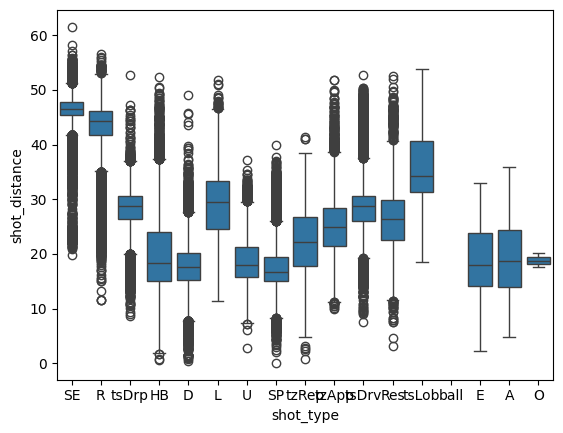

In [20]:
sns.boxplot(data= new_df, x='shot_type', y='shot_distance' )

### Serve relatiosnhip to Distance and Winning

<Axes: xlabel='shot_distance', ylabel='Count'>

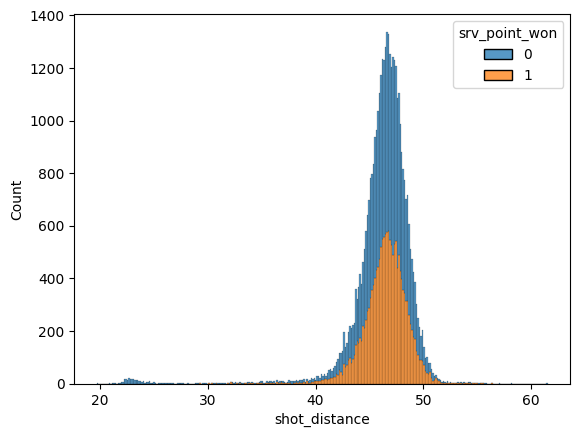

In [21]:
serving_df = new_df[new_df['shot_type'] == 'SE']

sns.histplot(data=serving_df, x='shot_distance', hue='srv_point_won', multiple='stack')

<Axes: xlabel='srv_point_won', ylabel='shot_distance'>

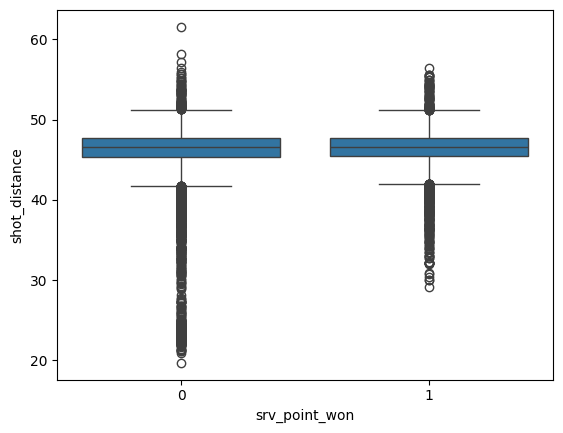

In [22]:
sns.boxplot(data= serving_df, x='srv_point_won', y='shot_distance' )

<Axes: xlabel='next_loc_y', ylabel='Percent'>

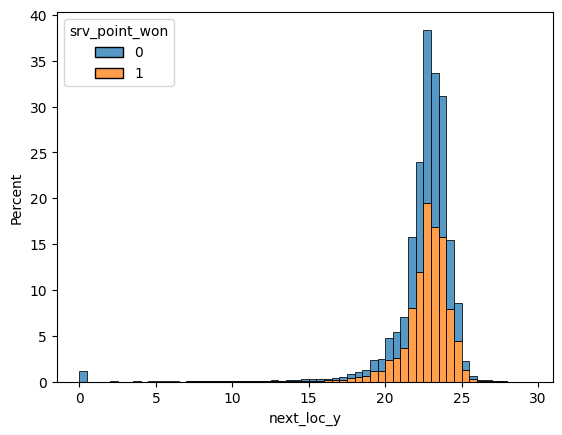

In [26]:
sns.histplot(data=serving_df, x='next_loc_y', hue='srv_point_won',
             multiple='stack', stat='percent', bins=np.arange(0,30,0.5), common_norm=False)

In [28]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Percent')

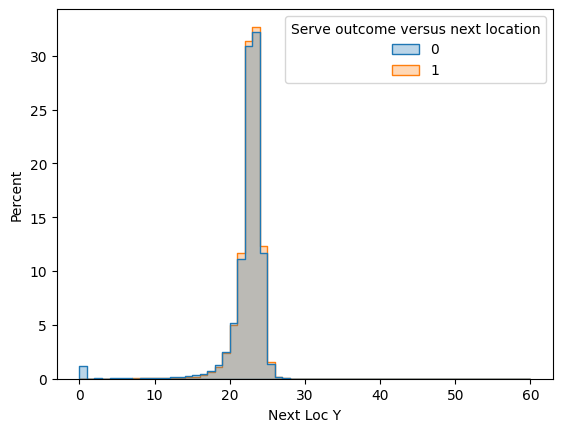

In [29]:
#mask = [(x in ['4.0', '4.5', '5.0']) for x in my_df['skill_lvl']]

ax = sns.histplot(data=serving_df, x='next_loc_y', hue='srv_point_won', stat='percent',
             bins = np.arange(0, 61, 1), alpha=0.3, common_norm=False,
             label='Avg Rating', element='step')

ax.get_legend().set_title('Serve outcome versus next location')
plt.xlabel('Next Loc Y')
plt.ylabel('Percent')

<Axes: xlabel='srv_point_won', ylabel='next_loc_y'>

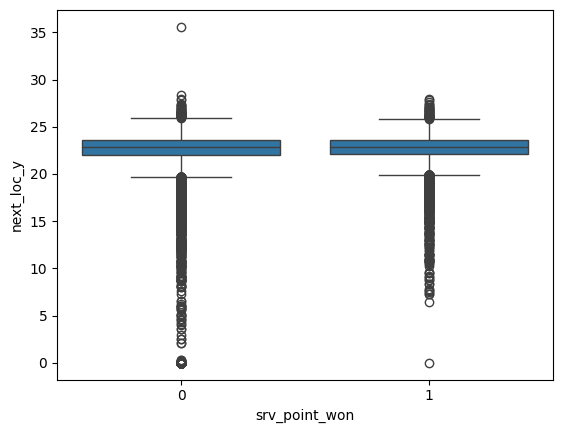

In [ ]:
sns.boxplot(data= serving_df, x='srv_point_won', y='next_loc_y' )

#### Does Third shot choice affect winning?

In [32]:
third_shot_df = new_df[new_df['shot_nbr'] == 3]

third_shot_df['shot_type'].value_counts()

,count
shot_type,
tsDrp,20062
tsDrv,15873
tsLob,589
U,8


<Axes: xlabel='shot_type', ylabel='count'>

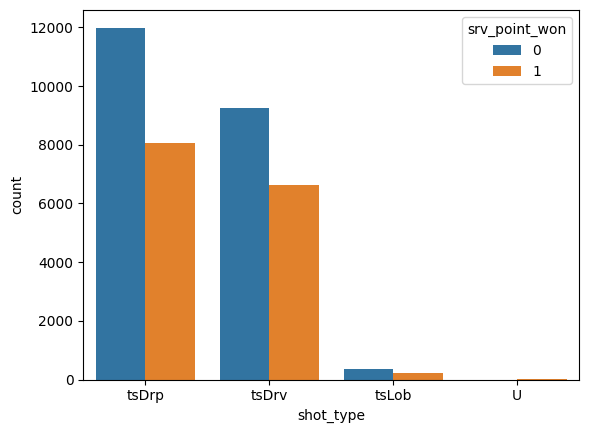

In [ ]:
sns.countplot(data=third_shot_df, x='shot_type', hue='srv_point_won')

<Axes: xlabel='srv_point_won', ylabel='next_loc_y'>

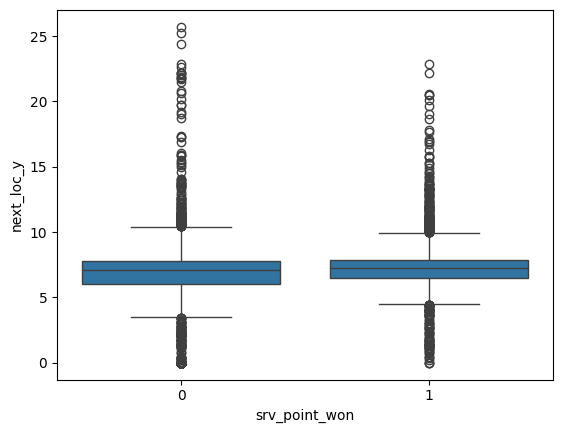

In [ ]:
third_shot_drp_df = third_shot_df[third_shot_df['shot_type'] == 'tsDrp']

sns.boxplot(data=third_shot_drp_df, x='srv_point_won', y='next_loc_y')

<Axes: xlabel='shot_type', ylabel='shot_distance'>

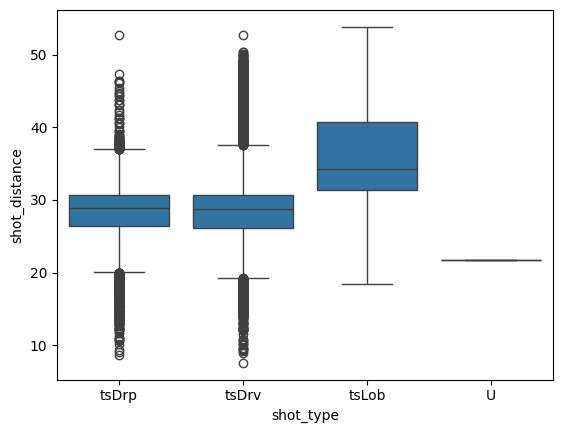

In [ ]:
sns.boxplot(data=third_shot_df, x='shot_type', y='shot_distance')

<Axes: xlabel='shot_type', ylabel='next_loc_y'>

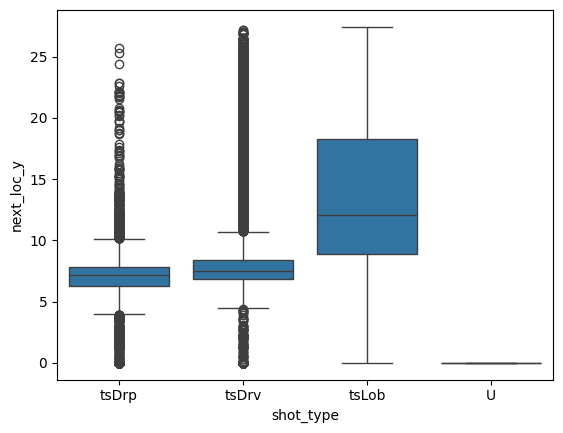

In [ ]:
sns.boxplot(data=third_shot_df, x='shot_type', y='next_loc_y')

<Axes: xlabel='shot_type', ylabel='rally_len'>

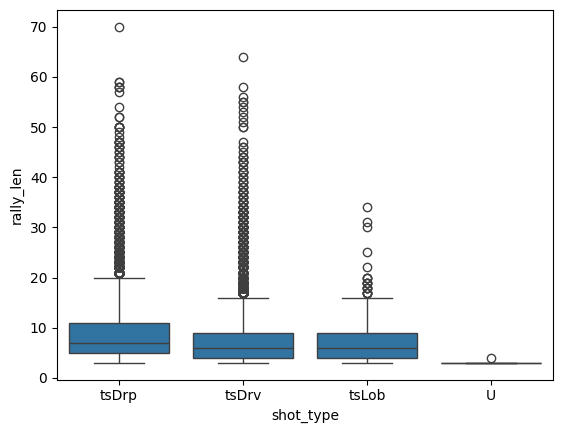

In [34]:
sns.boxplot(data=third_shot_df, x='shot_type', y='rally_len')

(0.0, 30.0)

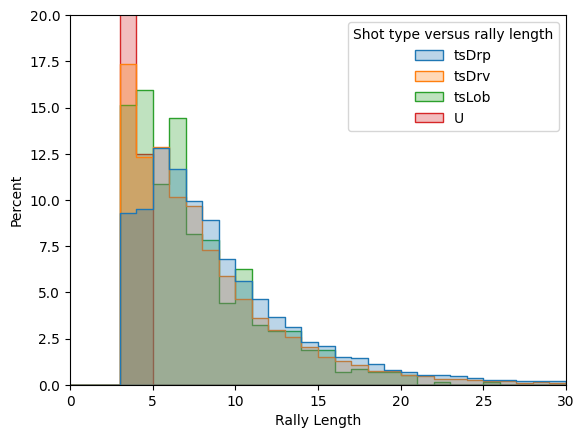

In [37]:
ax = sns.histplot(data=third_shot_df, x='rally_len', hue='shot_type', stat='percent',
             bins = np.arange(0, 61, 1), alpha=0.3, common_norm=False,
             label='Avg Rating', element='step')

ax.get_legend().set_title('Shot type versus rally length')
plt.xlabel('Rally Length')
plt.ylabel('Percent')

plt.ylim([0,20])
plt.xlim([0,30])

## Creating the modeling Data Frame

In this section we will be creating the data we wish to use to model the final data to be input into our model.

### The Model

The model that we have decided to use for the project will be an RNN (Recurrent Neural Network) as our plan for the predictive modeling stage is to be able to create a machine learning model that can accurately remodel the sequence of a rally based on given a certain amount of shots from the rally.